In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
df=pd.read_csv('/content/train.csv')

df

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0


In [ ]:
print(df.describe())
print(df.info())

                  id            age  alcohol_consumption_per_week  \
count  700000.000000  700000.000000                 700000.000000   
mean   349999.500000      50.359734                      2.072411   
std    202072.738554      11.655520                      1.048189   
min         0.000000      19.000000                      1.000000   
25%    174999.750000      42.000000                      1.000000   
50%    349999.500000      50.000000                      2.000000   
75%    524999.250000      58.000000                      3.000000   
max    699999.000000      89.000000                      9.000000   

       physical_activity_minutes_per_week     diet_score  sleep_hours_per_day  \
count                       700000.000000  700000.000000        700000.000000   
mean                            80.230803       5.963695             7.002200   
std                             51.195071       1.463336             0.901907   
min                              1.000000       0.1000

In [ ]:
df[df['diagnosed_diabetes']==1].describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.00000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.0
mean,349987.647755,51.820056,2.074849,73.473245,5.906678,7.00466,6.041372,26.109489,0.861159,117.211202,75.633393,70.296482,187.964860,53.481125,104.425668,124.825022,0.207895,0.190982,0.033623,1.0
std,201894.033765,11.593097,1.045364,43.428555,1.459453,0.90057,2.019437,2.852350,0.037819,11.031119,6.820969,6.917040,16.749371,8.310381,18.994343,24.852648,0.405802,0.393076,0.180257,0.0
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.20000,0.600000,15.100000,0.690000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,1.0
25%,175195.000000,44.000000,1.000000,46.000000,4.900000,6.40000,4.600000,24.200000,0.840000,109.000000,71.000000,66.000000,176.000000,48.000000,91.000000,108.000000,0.000000,0.000000,0.000000,1.0
50%,350061.000000,52.000000,2.000000,65.000000,5.900000,7.00000,6.000000,26.100000,0.860000,117.000000,76.000000,70.000000,188.000000,54.000000,104.000000,124.000000,0.000000,0.000000,0.000000,1.0
75%,524593.500000,60.000000,3.000000,90.000000,6.900000,7.60000,7.400000,28.000000,0.890000,125.000000,80.000000,75.000000,200.000000,59.000000,118.000000,140.000000,0.000000,0.000000,0.000000,1.0
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.90000,16.500000,38.400000,1.020000,163.000000,104.000000,101.000000,286.000000,90.000000,204.000000,286.000000,1.000000,1.000000,1.000000,1.0


In [ ]:
df[df['diagnosed_diabetes']==0].describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.0
mean,350019.110750,47.943484,2.068379,91.411873,6.058035,6.998129,5.965346,25.486175,0.854806,114.776907,75.122464,69.954747,184.922531,54.389237,100.391167,120.197593,0.052618,0.167111,0.024866,0.0
std,202368.458826,11.352802,1.052838,60.302019,1.464877,0.904101,2.027223,2.832044,0.037914,10.806463,6.821817,6.969243,16.526515,8.162087,18.800903,24.277571,0.223270,0.373076,0.155717,0.0
min,2.000000,19.000000,1.000000,3.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.0
25%,174688.000000,40.000000,1.000000,54.000000,5.100000,6.400000,4.500000,23.600000,0.830000,107.000000,70.000000,65.000000,173.000000,49.000000,87.000000,103.000000,0.000000,0.000000,0.000000,0.0
50%,349930.000000,48.000000,2.000000,79.000000,6.100000,7.000000,5.900000,25.500000,0.850000,115.000000,75.000000,70.000000,185.000000,54.000000,100.000000,120.000000,0.000000,0.000000,0.000000,0.0
75%,525604.000000,56.000000,3.000000,107.000000,7.100000,7.600000,7.300000,27.400000,0.880000,122.000000,80.000000,75.000000,197.000000,60.000000,114.000000,136.000000,0.000000,0.000000,0.000000,0.0
max,699995.000000,89.000000,9.000000,705.000000,9.900000,9.900000,15.900000,38.400000,1.050000,163.000000,104.000000,99.000000,289.000000,86.000000,205.000000,290.000000,1.000000,1.000000,1.000000,0.0


In [10]:
df['diagnosed_diabetes'].value_counts(normalize=True)

,proportion
diagnosed_diabetes,
1.0,0.623296
0.0,0.376704


In [ ]:
df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

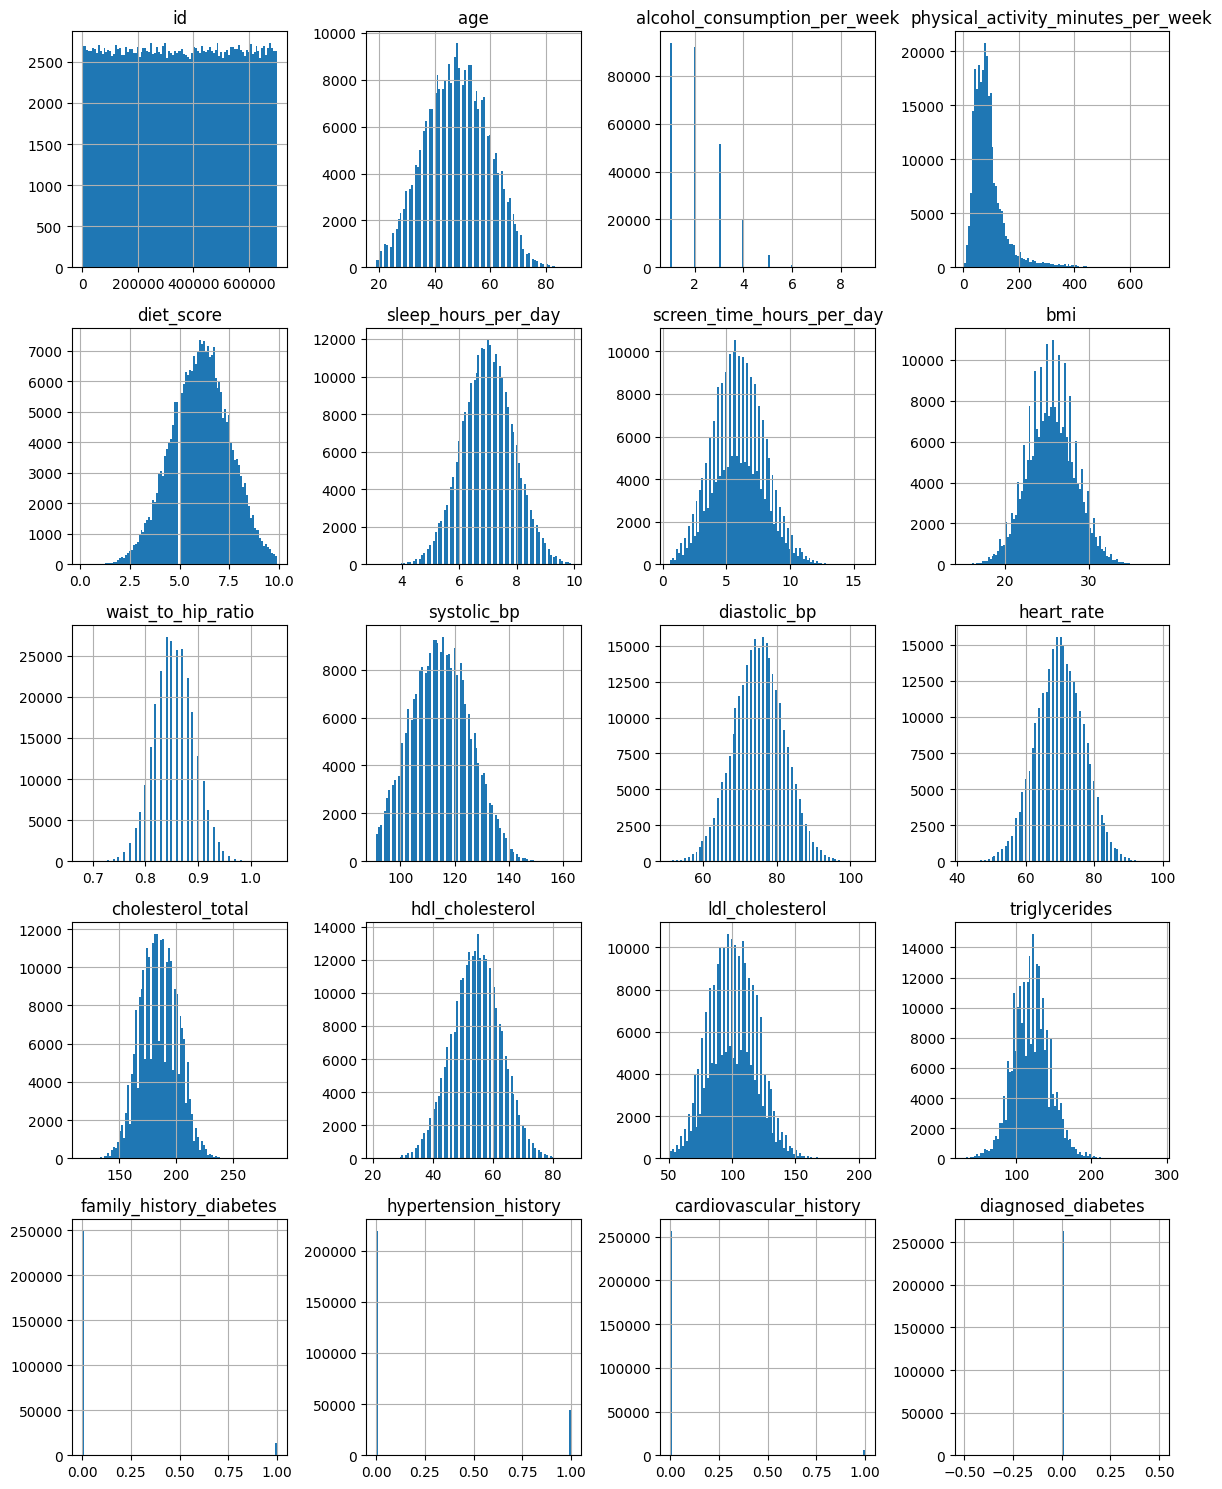

In [18]:
df[df['diagnosed_diabetes']==0].hist(figsize=(12,15),bins=100)
plt.tight_layout()

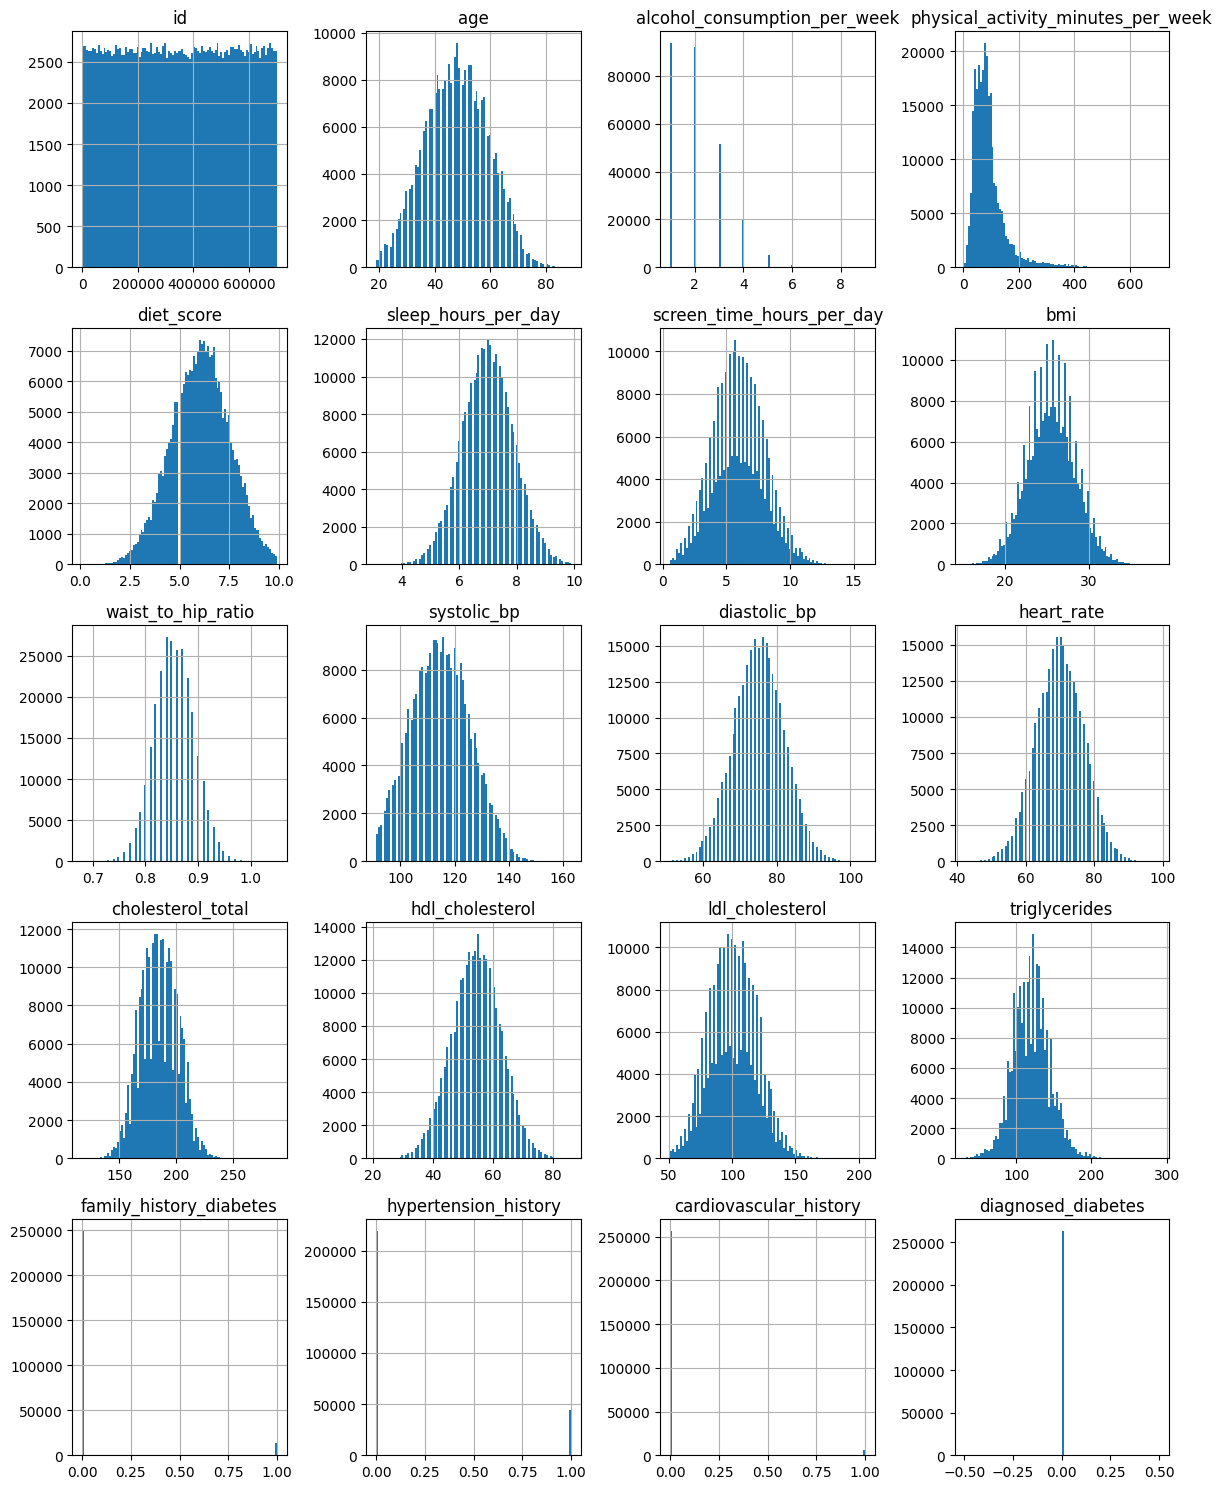

In [20]:
df[df['diagnosed_diabetes']==0].hist(figsize=(12,15),bins=100)
plt.tight_layout()

In [30]:
scaler=StandardScaler()
num_cols=['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides']

df[num_cols]=scaler.fit_transform(df[num_cols])

df.groupby(['gender','diagnosed_diabetes'])[num_cols].agg('mean')

age  alcohol_consumption_per_week  \
gender diagnosed_diabetes                                           
Female 0.0                -0.203399                     -0.001967   
       1.0                 0.126010                      0.003324   
Male   0.0                -0.211753                     -0.005601   
       1.0                 0.124787                      0.000902   
Other  0.0                -0.191813                     -0.033000   
       1.0                 0.100598                      0.032151   

                           physical_activity_minutes_per_week  diet_score  \
gender diagnosed_diabetes                                                   
Female 0.0                                           0.213213    0.065719   
       1.0                                          -0.131003   -0.038757   
Male   0.0                                           0.224240    0.063044   
       1.0                                          -0.133094   -0.039369   
Other  0.0                                           0.204224    0.069627   
       1.0                                          -0.130437   -0.022991   

                           sleep_hours_per_day  screen_time_hours_per_day  \
gender diagnosed_diabetes                                                   
Female 0.0                           -0.006432                  -0.025602   
       1.0                            0.002130                   0.012437   
Male   0.0                           -0.002147                  -0.021060   
       1.0                            0.003379                   0.016260   
Other  0.0                           -0.029277                  -0.021852   
       1.0                            0.002550                  -0.006148   

                                bmi  waist_to_hip_ratio  systolic_bp  \
gender diagnosed_diabetes                                              
Female 0.0                -0.135596           -0.102922    -0.134694   
       1.0                 0.084815            0.064282     0.087068   
Male   0.0                -0.135614           -0.105538    -0.141350   
       1.0                 0.079514            0.061731     0.079244   
Other  0.0                -0.176377           -0.121262    -0.125100   
       1.0                 0.046121            0.053839     0.077211   

                           diastolic_bp  heart_rate  cholesterol_total  \
gender diagnosed_diabetes                                                
Female 0.0                    -0.045668   -0.027676          -0.111851   
       1.0                     0.026931    0.016781           0.067777   
Male   0.0                    -0.047485   -0.034698          -0.115018   
       1.0                     0.029708    0.019789           0.069911   
Other  0.0                    -0.070692    0.034366          -0.109117   
       1.0                     0.016366    0.079387           0.013266   

                           hdl_cholesterol  ldl_cholesterol  triglycerides  
gender diagnosed_diabetes                                                   
Female 0.0                        0.072669        -0.132045      -0.113567  
       1.0                       -0.039937         0.079083       0.072998  
Male   0.0                        0.063250        -0.132173      -0.119930  
       1.0                       -0.042971         0.081325       0.068117  
Other  0.0                        0.127074        -0.150056      -0.113321  
       1.0                       -0.039767         0.031703       0.033990

In [26]:
df.groupby('diagnosed_diabetes')[num_cols].agg('std')

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides
diagnosed_diabetes,,,,,,,,,,,,,,,
0.0,0.974029,1.004436,1.177888,1.001053,1.002434,1.002233,0.989982,0.998270,0.981479,0.999421,1.004399,0.987789,0.987364,0.988356,0.981333
1.0,0.994645,0.997305,0.848296,0.997347,0.998519,0.998384,0.997080,0.995768,1.001883,0.999297,0.996876,1.001109,1.005304,0.998525,1.004578
